# 2.1. Logistic Regression behaviour

In [1]:
from anchoring_detection.models import Models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics
from mlxtend.plotting import plot_confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression

dataset = pd.read_pickle('/home/arturo/Documentos/Mooring_anomaly_detector/data/dataframe.pkl')

In [2]:
dataset

,Hs,Tp,Direction,m0_Surge,m0_Sway,Dragging
oc4__Hs1__Tp2__dir1__1,1.21,8.15,0,0.002438,0.001749,0
oc4__Hs1__Tp2__dir1__2,1.21,8.15,0,0.011784,0.008595,1
oc4__Hs1__Tp2__dir1__3,1.21,8.15,0,0.005411,0.005698,1
oc4__Hs1__Tp2__dir1__4,1.21,8.15,0,0.002285,0.003390,1
oc4__Hs1__Tp2__dir2__1,1.21,8.15,60,0.002250,0.001852,0
...,...,...,...,...,...,...
oc4__Hs4__Tp5__dir3__2,8.10,18.69,90,0.012230,0.018121,1
oc4__Hs4__Tp5__dir4__1,8.10,18.69,120,0.005428,0.010878,0
oc4__Hs4__Tp5__dir4__2,8.10,18.69,120,0.012206,0.016706,1
oc4__Hs4__Tp5__dir5__1,8.10,18.69,180,0.011085,0.002734,0


## Prepare data

The user can apply transformations described in [*notebook 2.0*](2_0_Data_fundamentals.ipynb)

In [3]:
drag_models = Models()

In [4]:
X_train_min_max, X_test_min_max, Y_train, Y_test = drag_models.transform_dataset(dataset)

The training set contains the Surge and Sway spectral moments in a 2D array

In [5]:
X_train_min_max

array([[0.00698358, 0.08528962],
       [0.01479205, 0.00191339],
       [0.00537408, 0.10163946],
       [0.07170368, 0.64738316],
       [0.13279204, 0.22928384],
       [0.97379166, 0.44280775],
       [0.02292324, 0.00992097],
       [0.02498603, 0.26900404],
       [0.03661853, 0.00448592],
       [0.46194614, 0.04524715],
       [0.05851568, 0.04525578],
       [0.80010464, 0.28760974],
       [0.00234019, 0.02315467],
       [0.59827887, 0.44251679],
       [0.54892333, 0.06513841],
       [0.59337273, 0.42081638],
       [0.60988548, 0.40667915],
       [0.57558169, 0.42438641],
       [0.67948669, 0.43384154],
       [0.        , 0.02048375],
       [0.61626008, 0.27170729],
       [0.66738549, 0.46234012],
       [0.58478244, 0.42107766],
       [0.02389493, 0.39263281],
       [0.12769059, 0.15162937],
       [0.07700594, 0.10509197],
       [0.61160497, 0.42066791],
       [0.65091093, 0.41372954],
       [0.00869242, 0.01133714],
       [0.01081056, 0.18879129],
       [0.

The approach of training is with supervised learning. It is store the data according two class, **Healthy (0)** and **Draging (1)**

In [6]:
Y_train

oc4__Hs1__Tp5__dir3__1    0
oc4__Hs1__Tp3__dir1__1    0
oc4__Hs1__Tp3__dir1__4    1
oc4__Hs4__Tp5__dir3__1    0
oc4__Hs2__Tp5__dir2__1    0
                         ..
oc4__Hs3__Tp5__dir5__1    0
oc4__Hs1__Tp3__dir1__3    1
oc4__Hs3__Tp4__dir4__1    0
oc4__Hs2__Tp3__dir1__4    1
oc4__Hs3__Tp5__dir3__1    0
Name: Dragging, Length: 96, dtype: int64

## First training

Check how model perform without hyperparams

In [7]:
model = LogisticRegression()

In [8]:
model.fit(X_train_min_max,Y_train)

LogisticRegression()

Can be made cross validation and see the metrics

In [9]:
train_pred = cross_val_predict(model,X_train_min_max, Y_train, cv=5)

In [10]:
cm, df_metrics =drag_models.return_metrics(Y=Y_train, Y_pred=train_pred)

In [11]:
df_metrics

,accuracy,precision,recall,f1
0,0.802083,0.827586,0.842105,0.834783


Text(0.5, 1.0, 'Logistic Regression')

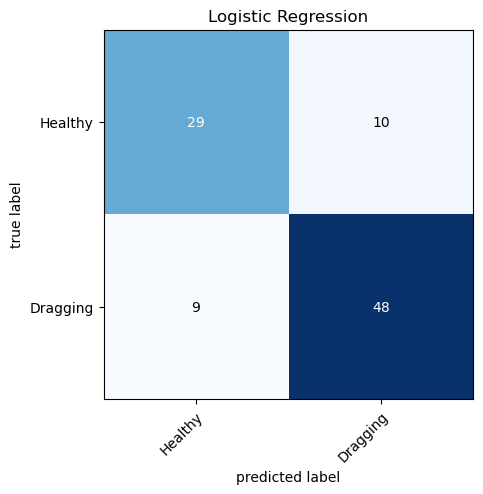

In [12]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Logistic Regression')

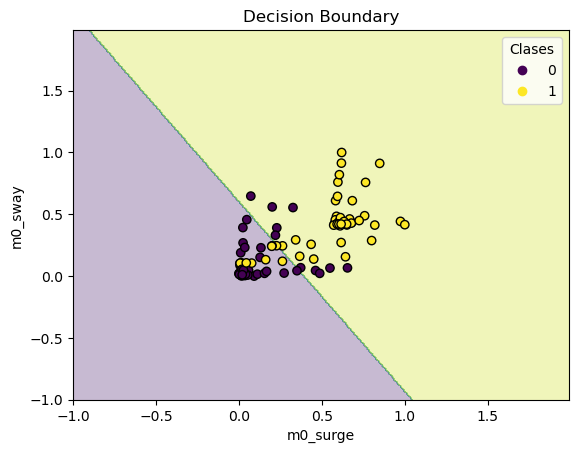

In [13]:
drag_models.decision_boundary(model=model,X=X_train_min_max,y=Y_train)

## Hyperparams selection

Apply hyperparams to improve the model performance. The main target is reduce the "false healthy states" to the confusion matrix. More information about that in documentation

In [14]:
param_grid = [
    {'C':[1, 10, 50, 100],'penalty':['l1','l2'],'solver':['liblinear']}
    ]

grid_search = GridSearchCV(model, param_grid,  cv=5, scoring= ['accuracy','precision','recall','f1'],refit='accuracy', return_train_score=True)

grid_search.fit(X_train_min_max,Y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid=[{'C': [1, 10, 50, 100], 'penalty': ['l1', 'l2'],
                          'solver': ['liblinear']}],
             refit='accuracy', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1'])

In [15]:
hyperparams = pd.DataFrame(grid_search.cv_results_)
metric_columns = ['param_C', 'param_penalty', 'param_solver', 'mean_train_accuracy', 'mean_train_precision', 'mean_train_recall', 'mean_train_f1']

hyperparams = hyperparams[metric_columns]

hyperparams

,param_C,param_penalty,param_solver,mean_train_accuracy,mean_train_precision,mean_train_recall,mean_train_f1
0,1,l1,liblinear,0.807211,0.841713,0.833333,0.837309
1,1,l2,liblinear,0.807280,0.813484,0.877198,0.843873
2,10,l1,liblinear,0.796890,0.835178,0.820193,0.827560
3,10,l2,liblinear,0.794293,0.831339,0.820193,0.825704
4,50,l1,liblinear,0.802085,0.842688,0.820193,0.831232
5,50,l2,liblinear,0.796890,0.835178,0.820193,0.827560
6,100,l1,liblinear,0.802085,0.842688,0.820193,0.831232
7,100,l2,liblinear,0.799487,0.838849,0.820193,0.829376


In [16]:
grid_search.best_params_

{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}

## New training

Retraining model with hyperparameters

In [17]:
model = LogisticRegression(C=10,penalty='l1',solver='liblinear')

In [18]:
model.fit(X_train_min_max,Y_train)

LogisticRegression(C=10, penalty='l1', solver='liblinear')

In [19]:
train_pred = cross_val_predict(model,X_train_min_max, Y_train, cv=5)

In [20]:
cm, df_metrics =drag_models.return_metrics(Y=Y_train, Y_pred=train_pred)

With this model, hyperparameters do not improve performance or reduce "false healthy states".

In [21]:
df_metrics

,accuracy,precision,recall,f1
0,0.802083,0.839286,0.824561,0.831858


Text(0.5, 1.0, 'Logistic Regression')

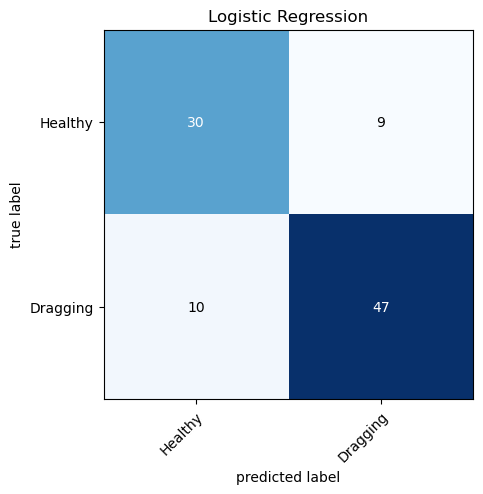

In [22]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Logistic Regression')

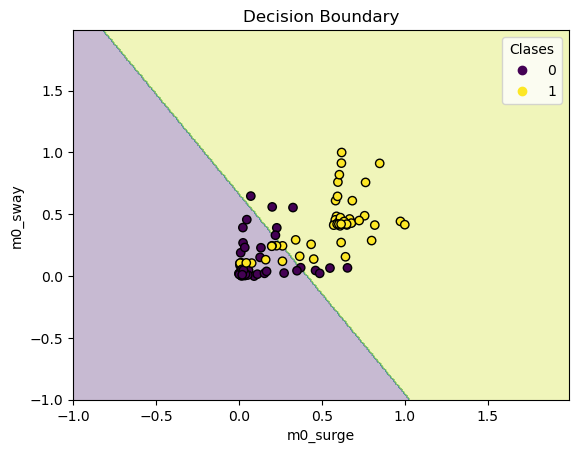

In [23]:
drag_models.decision_boundary(model=model,X=X_train_min_max,y=Y_train)

## Predictions

In [24]:
Y_pred_test = model.predict(X_test_min_max)

ATTENTION: Note that you are now working with model test arrays.

In [25]:
cm, df_metrics =drag_models.return_metrics(Y=Y_test, Y_pred=Y_pred_test)

Considering few test data, therefore 100% accuracy metrics can be observed (probably for overfitting). However, for the current data volume, the model trains correctly, with only one ‘false healthy’ cases.

In [26]:
df_metrics

,accuracy,precision,recall,f1
0,0.958333,1.0,0.923077,0.96


Text(0.5, 1.0, 'Logistic Regression')

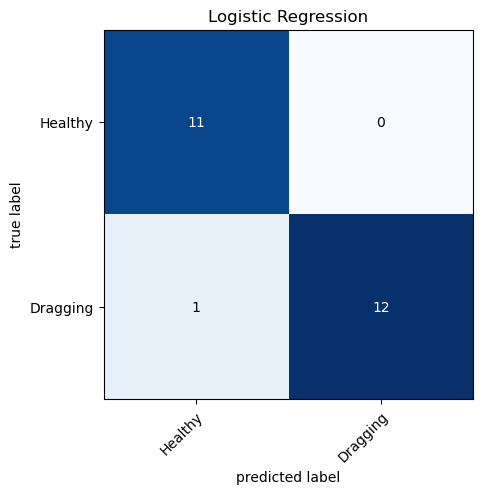

In [27]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Logistic Regression')

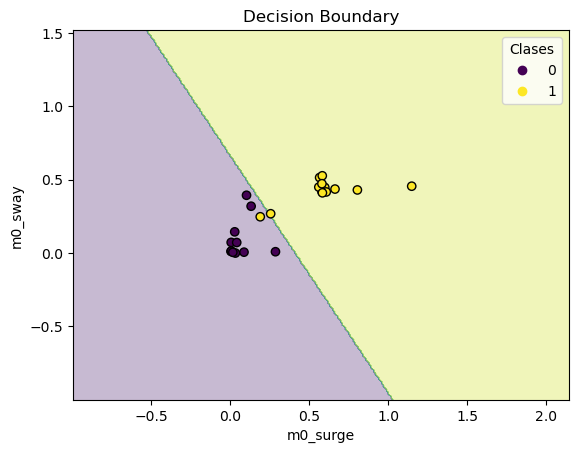

In [28]:
drag_models.decision_boundary(model=model,X=X_train_min_max,y=Y_train)